<b> Title: </b> Understanding Performance Dynamics in Modern Formula 1

<b> Overall Topic: </b> Analysing the relationship between qualifying performance and race outcomes as well as intra-team competitive dynamics using data from 2018 to 2024 from the datasource FastF1. 

<b> Research Question 1: </b>  Qualifying-Race Performance Correlation

<u> “What is the relationship between qualifying session performance metrics and final race standings across different circuits, seasons, and regulatory eras?” </u>

<u> <i> <center> 1a) Does the qualifying-race relationship change depending on the context of circuit type and overtaking difficulty? </center> </i> </u>

<u> <i> <center> 1b) Do the regulations affecting overtaking introduced in 2022 affect the qualifying-race correlation? </center> </i> </u>

<b> Motivation </b> This question is motivated by the limited resources of F1 teams to answer a part of prioritisation. As there are so many elements and considerations involved with each race, it is unclear what drivers and teams should foucs on. One fact that is commonly accepted is that the qualifying races, which determines a driver's starting position in the final race, is extremely important. It is true that a better starting position does generally imply a stronger finish, however the thrill of F1 is the uncertainty of not knowing when another driver will fall behind or overtake. As such, there are predictors that a viewer cannot estimate which nonetheless still contribute to a driver's position. We formulate that some of these may be the circuit type as well as the regulatory era and we set out to explore these factors.

This notebook studies the above questions using various statistical analyses, further detailed in the table of contents below. The aim of this notebook is to aid in producing a report that is well supported by data. We do this through consturcting two datasets, one for an elastic net multinomial logistic regression and another for a time series analysis which is implemented in R. 

Some of the <b> key outputs </b> of this report are descriptive EDA graphs, cross-validated model performance metrics, subgroup comparisons, and within-rice dependence summaries. For transparency, I have tried to thoroguhly explain and justify the use of each statistical tool within the notebook, but the overall conclusion and further discussion in implemented in the report that this notebook complements. 

<b> Table of Contents <b>
    
    - Introduction
    - Environment Setup
        - FastF1
        - Importing Packages
        - Defining Variables Globally
    - Data Construction
        - Event-Outcome Dataset (is this right?)
        - Event-Driver Data set
        - Circuit Mapping
        - Extracting Data
    - Exploratory Data Analysis
        - Data Balance
        - Spearman Correlation
        - Plots
        - Distribution
    - Multinomial Logistic Regression Base Model with Elastic-Net Regularisation
        - Pre-processing Pipeline
        - SGD Classifier
        - Cross Validation
        - Model Evaluation using a Confusion Matrix
    - Model 2: Adding Interaction Terms
        - QualiPos x Era
        - QualiPos x CircuitType
        - Both
    - Time Series
    - Evaluation

<b>1. Introduction to the Code Progression</b>

In the code below, I've tried to use a logical approach and group things together in sections. First is the usual data pre-processing and eda. The main part is the multinomial logistic regression model, where below I have explanations for why I chose to use this model with elastic-net regularisation and other model specifics. The base model doesn't have any interaction terms and I assume the relationship is constant between the factors I am evaluating. Then I add interaction terms to see if the slope itself varies, which should make the model more accurate if my hypothesis of regulatory changes affecting overtaking is correct. I'll then do some further time series analysis to investigate more relationships.

<b>2. Environment Setup </b>

The steps below are the ones necessary to run the code and replicate our data analysis process.

<i> <b> FastF1</b> </i>  First is downloading the data itself which is very simple through !pip install. Then I ensure local caching so that the downloaded sessions are stored and reused to make the code efficient. I'm also turning off warnings for a cleaner output.

In [2]:
# !pip install fastf1
import fastf1

import os
os.makedirs("fastf1_cache", exist_ok=True) 
fastf1.Cache.enable_cache("fastf1_cache") # enabling cache locally

# ignoring warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

<i><b>Importing Packages</b></i> For this progect, I use pandas and numpy for data handling, matplotlib and seaborn for visualising, and scikit-learn for the multinomial model

In [3]:
import numpy as np 
import pandas as pd 
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid") 

from sklearn.model_selection import train_test_split, StratifiedKFold 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
confusion_matrix, ConfusionMatrixDisplay, roc_auc_score) 
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import FunctionTransformer

<i><b>Defining Variables Globally</b></i> From the very start, I want to be clearer about how we're processing the data. So for transparency, we're using the years 2018-2024. We chose 2024 because at the time of initial exploration, the 2025 session wasn't complete, and 2018 because the race style changes prior to the year, making analysis of those years unreliable.

We further add a column to classify the years as pre-2022 and post-2022 to use for analysis of the regulation that was introduced in 2022.

For race outcome, instead of just using the race finishing position from 1-20, we're doing it in categories for easier comparision. We decided on 3-class multinomial so first is positions 1-3 which we'll call "Podium", 4-10 as "Points", and 11-20 as "NoPoints". Another reason for this is smaple size per class, we want this to be more full which is why i've grouped classes together.

We're using qualifying races and normal races which we'll denote the sessions as either "Q" for qualifying or "R". 

I'm also defining a random seed here to ensure reproducibility in the data splits and cross-validations.

In [4]:
# defining years in analysis
START_YEAR = 2018
END_YEAR = 2024
YEARS = list(range(START_YEAR, END_YEAR + 1))

ERA_SPLIT_YEAR = 2022 # when regulation was introduced

# defining ttype of session
QUALI_SESSION = "Q" 
RACE_SESSION = "R"

# definign outcome function
def define_outcome(race_pos): 
    if pd.isna(race_pos): 
        return np.nan
    elif race_pos <= 3: 
        return "Podium"
    elif race_pos <= 10: 
        return "Points"
    else:
        return "NoPoints"
    
# setting random seed
RANDOM_SEED = 5 
np.random.seed(RANDOM_SEED)

<b>3. Data Construction </b>

In this section, I derive the dataset used for my multinomial logistic regression model. In this, I have one row as the Year, Round, Event, Driver --> Qualifying Performance --> Race Outcome, as that is the necessary informaiton for the model.

<i><b>Event-Driver Dataset</b></i>
I use, Qualifying session results (Q), Race session results (R), Merge them using Driver. I then derive labels for Era, Circuit Type (which I define by myself, further explanation below), and Race Outcome (dividing into the 3 categories).


In [17]:
def get_race_schedule(year):
    schedule = fastf1.get_event_schedule(year)
    
    # keeping only conventional race weekends
    schedule = schedule[schedule["EventFormat"].isin(["conventional", "sprint"])]
    
    # I don't want to include test races
    schedule = schedule[~schedule["EventName"].str.contains("Test", case=False)] 
    schedule = schedule.reset_index(drop=True)
    return schedule

# putting all together
all_schedules = []

for year in YEARS:
    schedule_year = get_race_schedule(year) 
    schedule_year["Year"] = year 
    all_schedules.append(schedule_year)

schedule_df = pd.concat(all_schedules, ignore_index=True)

print("Number of events extracted:", len(schedule_df)) 
schedule_df.head() # examining data

Number of events extracted: 137
   Year              EventName
0  2018  Australian Grand Prix
1  2018     Bahrain Grand Prix
2  2018     Chinese Grand Prix
3  2018  Azerbaijan Grand Prix
4  2018     Spanish Grand Prix
Year
2018    21
2019    21
2020    17
2021    22
2022    22
2023    16
2024    18
dtype: int64


<i><b>Circuit Mapping</b></i>
Because the dataset doesn't have its own categories for track type, I manually categorised them. As I'm no expert, I tried consolidating all information online about track type and any previous categorisations that already exist. I used the circuit guide from Formula1.com and FIA documentation as well as some research papers which give further insight. Some are very obviously one category while others are in-betweens or harder to define.

These are meant to reflect overtaking difficulty. I decided on three main categories that are usually used by people when talking about F1. A street type is narrower than usual with more bends, making overtaking difficult. HighSpeed indicates circuit types that allow for drivers to go faster, which is partly categorised by the average speed but also by longer straights and less curves or more open curves. And then finally the technical category, which is middle ground for both and is an even balanced mix of straights and curves and normal speed. For ones that were a little ambiguous to categorise, and didn't look to fit either High Speed or Street, I put them as technical.

In [21]:
# Circuit Type Mapping 
CIRCUIT_TYPE_MAP = {
    
    # Street, narrow least overtaking
    "Monaco Grand Prix": "Street",
    "Singapore Grand Prix": "Street",
    "Azerbaijan Grand Prix": "Street",
    "Las Vegas Grand Prix": "Street",
    "Miami Grand Prix": "Street",
    "Australian Grand Prix": "Street",
    "Canadian Grand Prix": "Street",
    
    # High Speed, long straight, very fast, most overtaking
    "Italian Grand Prix": "HighSpeed",
    "Belgian Grand Prix": "HighSpeed",
    "Saudi Arabian Grand Prix": "HighSpeed",
    "British Grand Prix": "HighSpeed",
    "Austrian Grand Prix": "HighSpeed",
    "Mexican Grand Prix": "HighSpeed",
    "São Paulo Grand Prix": "HighSpeed",
    "Brazilian Grand Prix": "HighSpeed",
    "Japanese Grand Prix": "HighSpeed",
    "Dutch Grand Prix": "HighSpeed",
    "Qatar Grand Prix": "HighSpeed",
              
    # Technical, middle ground, balanced, and the default if undefinable
    "Bahrain Grand Prix": "Technical",
    "Chinese Grand Prix": "Technical",
    "Spanish Grand Prix": "Technical",
    "Hungarian Grand Prix": "Technical",
    "French Grand Prix": "Technical",
    "German Grand Prix": "Technical",
    "United States Grand Prix": "Technical",
    "Emilia Romagna Grand Prix": "Technical",
    "Portuguese Grand Prix": "Technical",
    "Turkish Grand Prix": "Technical",
    "Dutch Grand Prix": "Technical",
    "Abu Dhabi Grand Prix": "Technical"
}

def assign_circuit_type(event_name): 
    if isinstance(event_name, str):
        event_name = event_name.strip()
    return CIRCUIT_TYPE_MAP.get(event_name, "Technical") # setting technical as default

<b> <i> Extracting Data Function: </i> </b> 
Returns the merged qualifying and race results for one event, so one draw for each driver. Because there's an API limit of 500 per hour, I'm strictly only getting the information that is necessary as loading it takes time.

In [22]:
def get_event_driver_data(year, round_number, event_name): 
    try:
    # loading qualifying
        quali = fastf1.get_session(year, round_number, QUALI_SESSION) 
        quali.load(telemetry=False, laps=False, weather=False)
                  
    # skips if missing results
        if quali.results is None or len(quali.results) == 0: 
            return None

        q_results = quali.results.copy()
    
        # Using the best available qualifying time so Q3 if exists else Q2 else Q1
        q_results["QualiTime"] = ( 
            q_results["Q3"].fillna(q_results["Q2"]).fillna(q_results["Q1"])
        )
    
        # only the necessary information
        q_keep = q_results[["DriverNumber", "Abbreviation", "FullName", "TeamName",
        "Position", "Q1", "Q2", "Q3", "QualiTime"]].rename(columns={"Position": "QualiPos"})
    
        # loading final race
        race = fastf1.get_session(year, round_number, RACE_SESSION) 
        race.load(telemetry=False, laps=False, weather=False)
    
        # skipping if missing results
        if race.results is None or len(race.results) == 0: 
            return None
    
        r_results = race.results.copy()
    
        r_keep = r_results[[ "DriverNumber", "Abbreviation", "Position", "GridPosition", "Status"
        ]].rename(columns={"Position": "RacePos", "GridPosition": "StartPos"}) # merging on driver

        df = pd.merge(q_keep, r_keep, on=["DriverNumber", "Abbreviation"], how="inner")
                  
        # skipping if merge doesn't work
        if len(df) == 0: 
            return None
        
        # getting more necessary info
        df["Year"] = year 
        df["Round"] = round_number 
        df["EventName"] = event_name
        
        # adding the era label
        df["Era"] = np.where(df["Year"] < ERA_SPLIT_YEAR, "Pre-2022", "Post-2022") 
    
        # categorising circuit type using function defined previously
        df["CircuitType"] = df["EventName"].apply(assign_circuit_type) 
        
        
        # making it numeric to avoid errors later on
        for col in ["QualiPos", "RacePos", "StartPos"]: 
            df[col] = pd.to_numeric(df[col], errors="coerce")
            
        # categorsing the outcome into categories defined previously
        df["Outcome"] = df["RacePos"].apply(define_outcome)
        
        return df

    # for catching errors
    except Exception as e:
        print(f"Error in {year} {event_name}: {e}")
        return None

<b> <i>API Call Limit </i> </b>
There is an api limit of 500 per hour so you have to run the api several times across different hours. This is also why i'm extracting the minimum amount of information so it's minimal reruns. Using cache, I can store the information so I don't reuse the API calls on the same data. For reproducibility and anyone else who would like to check witht he data, I've saved the loaded data into a csv so they don't have to go through the hassle of running the code multiple times to get the data.

In [50]:
%%capture
import logging
logging.getLogger("fastf1").setLevel(logging.CRITICAL)
# ^ to hide the output

event_driver_data = []

for idx, row in schedule_df.iterrows():
    year = row["Year"]
    round_number = row["RoundNumber"]
    event_name = row["EventName"]
    df_event = get_event_driver_data(year, round_number, event_name)
   
    if df_event is not None: 
        event_driver_data.append(df_event)
        
# combining to final dataset
event_driver_df = pd.concat(event_driver_data, ignore_index=True)

<b> <i> Data Checks </i> </b>
Because of the API call limit, I have to run the code multiple times and then check to see that all races have been imported correctly and that I don't have any duplicates or any other data errors.

In [24]:
# checking that all races have been imported

print("Total rows:", event_driver_df.shape[0])
print("Years covered:")
print(event_driver_df["Year"].value_counts().sort_index())

event_driver_df.head()

Total rows: 2739
Years covered:
2018    420
2019    420
2020    340
2021    440
2022    440
2023    320
2024    359
Name: Year, dtype: int64


,DriverNumber,Abbreviation,FullName,TeamName,QualiPos,Q1,Q2,Q3,QualiTime,RacePos,StartPos,Status,Year,Round,EventName,Era,CircuitType,Outcome
0,44,HAM,Lewis Hamilton,Mercedes,1.0,0 days 00:01:22.824000,0 days 00:01:22.051000,0 days 00:01:21.164000,0 days 00:01:21.164000,2.0,1.0,Finished,2018,1,Australian Grand Prix,Pre-2022,Street,Podium
1,7,RAI,Kimi Räikkönen,Ferrari,2.0,0 days 00:01:23.096000,0 days 00:01:22.507000,0 days 00:01:21.828000,0 days 00:01:21.828000,3.0,2.0,Finished,2018,1,Australian Grand Prix,Pre-2022,Street,Podium
2,5,VET,Sebastian Vettel,Ferrari,3.0,0 days 00:01:23.348000,0 days 00:01:21.944000,0 days 00:01:21.838000,0 days 00:01:21.838000,1.0,3.0,Finished,2018,1,Australian Grand Prix,Pre-2022,Street,Podium
3,33,VER,Max Verstappen,Red Bull Racing,4.0,0 days 00:01:23.483000,0 days 00:01:22.416000,0 days 00:01:21.879000,0 days 00:01:21.879000,6.0,4.0,Finished,2018,1,Australian Grand Prix,Pre-2022,Street,Points
4,3,RIC,Daniel Ricciardo,Red Bull Racing,5.0,0 days 00:01:23.494000,0 days 00:01:22.897000,0 days 00:01:22.152000,0 days 00:01:22.152000,4.0,8.0,Finished,2018,1,Australian Grand Prix,Pre-2022,Street,Points


In [25]:
# checking that i didn't import any duplicates
duplicate_check = event_driver_df.duplicated(subset=["Year", "Round", "Abbreviation"]).sum() 
duplicate_check

0

In [26]:
# checking missing
print("Total missing values in dataset:")
print(event_driver_df.isna().sum())

Total missing values in dataset:
DriverNumber       0
Abbreviation       0
FullName           0
TeamName           0
QualiPos         163
Q1               197
Q2               840
Q3              1481
QualiTime        195
RacePos          143
StartPos         143
Status             0
Year               0
Round              0
EventName          0
Era                0
CircuitType        0
Outcome          143
dtype: int64


The missing for qualifying races is expected as only some drivers make it to the next round and from that even less make it to next

In [27]:
# dropping
event_driver_df[event_driver_df["QualiPos"].isna()][["Year","Round","EventName"]].drop_duplicates()

,Year,Round,EventName
478,2019,3,Chinese Grand Prix
1279,2021,5,Monaco Grand Prix
1540,2021,19,São Paulo Grand Prix
1600,2021,22,Abu Dhabi Grand Prix
1680,2022,4,Emilia Romagna Grand Prix
1700,2022,5,Miami Grand Prix
1760,2022,8,Azerbaijan Grand Prix
1780,2022,9,Canadian Grand Prix
1860,2022,13,Hungarian Grand Prix
2020,2022,21,São Paulo Grand Prix


In [28]:
# Checking basic stats that could help me later on while creating model
event_driver_df[["QualiPos", "RacePos", "StartPos"]].describe()

,QualiPos,RacePos,StartPos
count,2576.000000,2596.000000,2596.000000
mean,10.474379,10.485362,10.203775
std,5.748729,5.759752,5.804563
min,1.000000,1.000000,0.000000
25%,5.000000,5.000000,5.000000
50%,10.000000,10.000000,10.000000
75%,15.000000,15.000000,15.000000
max,20.000000,20.000000,20.000000


Pretty uniform across grid positions and values are consistent with expected

In [29]:
# to get the number of races each year and to check it aligns with expected.
event_driver_df.groupby("Year")["Round"].nunique()

Year
2018    21
2019    21
2020    17
2021    22
2022    22
2023    16
2024    18
Name: Round, dtype: int64

below i'm dropping rows where outcome, qualipo, and racepos is missing to ensure valid dependent variables
and key predictors

In [30]:
# saving final dataset
event_driver_df.to_csv("../data/event_driver_df.csv", index=False)

<b>4. Exploratory Data Analysis</b>

The aim of this section is to explore the relationship between qualifying position and race finishing position before I fit any statistical model. I'll analyse the class balance of the outcome variable to see if any further balancing is required, the distribution of the race positions, the spearman rank correlation, and the dependence both by circuit type and era. These descriptive analyses directly motivate my model; the subsequent multinomiall logistic regression. 

<i><b>Data Balance</b></i> In the previous section, I already started to validate the dataset after loading and constructing the data. I'll continue to do so to make sure my data is reasonable and usable and to see if there are any further tweaks I must make if necessary. 

In [31]:
# checking class balance
event_driver_df["Outcome"].value_counts(normalize=True)
# not balanced enough so benefit from using class_weight= 'balanced'

NoPoints    0.499230
Points      0.350539
Podium      0.150231
Name: Outcome, dtype: float64

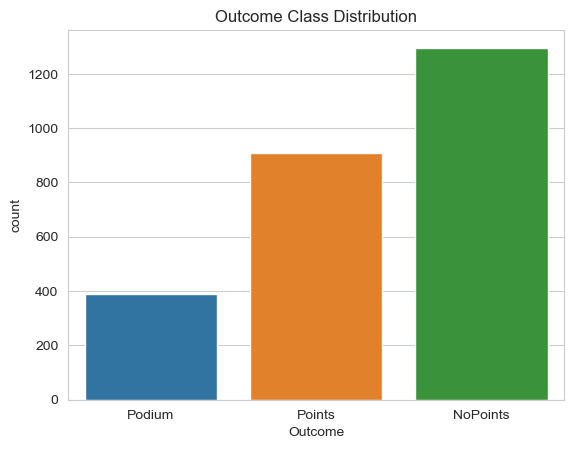

In [32]:
# Class balance
sns.countplot(data=event_driver_df, x="Outcome") 
plt.title("Outcome Class Distribution") 
plt.show()

This is the expected balance, as less drivers earn points and even less make it to the podium. There is a very clear difference so to make the results as accurate as possible, I will balance the class weights and also use macro-averages, to ensure Podium is not under-represented in data evaluation.

<i><b>Qualifying vs. Race Performance</b></i>
To examing the relationship, I'm simply plotting qualifying against final race position which, as expected, gived a strong correlation. Using spearman's rank correlation, I get ρ = 0.645, so a strong association. I'm using spearman's instead of any other because both variables have ordinal rankings and it is possible the relationship is not linear. 

<i><b>Position Change Analysis</b></i>
This is the main thing I'm investigating, so I loook into it first without any other factor consideration. I'm defining position change as the difference between the race finish posiiton (RacePos) and the qualifying position (QualiPos) which determines starting position. 

<i> <u> Result </u></i> The distribution is centred around zero, which indicates that the majority of drivers finish close to their qualifying position, which in my hypothesis would mean that qualifying position does greatly affect. However, there is a lot of variability as can be seen by the heavy tails, so qualifying, while a strong predictor, is not perfect. There may be some deep within race variability caused by external factors, which then motivates the next part of my EDA; looking into circuit analysis and era analysis.


In [34]:
# creating a clean dataset for qualifying position and final race position
eda_df = event_driver_df.dropna(subset=["QualiPos", "RacePos"]).copy()

# calculating position change for easier visualisationg
eda_df["PosChange"] = eda_df["RacePos"] - eda_df["QualiPos"]

# overall spearman correlation
rho, p = stats.spearmanr(eda_df["QualiPos"], eda_df["RacePos"])
print("overall spearman correlation:", rho)

overall spearman correlation: 0.6452791902979124


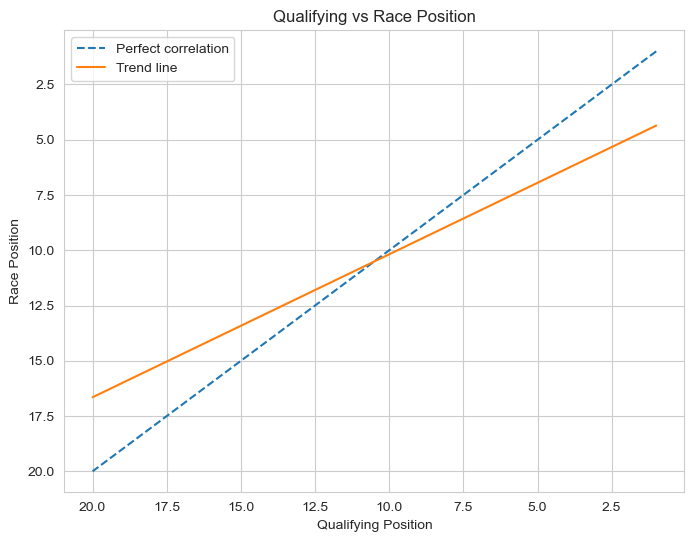

In [37]:
# scatter plot to show correlations

plt.figure(figsize=(8,6))

# perfect line
plt.plot([1,20], [1,20], "--", label="Perfect correlation")

# trend line
z = np.polyfit(eda_df["QualiPos"], eda_df["RacePos"], 1)
plt.plot([1,20], np.poly1d(z)([1,20]), label="Trend line")

# adding labels
plt.xlabel("Qualifying Position")
plt.ylabel("Race Position")
plt.title("Qualifying vs Race Position")

# invert axes to show overtaking better
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.legend()
plt.show()

count    2434.000000
mean        0.016023
std         4.848226
min       -18.000000
25%        -3.000000
50%         0.000000
75%         2.000000
max        19.000000
Name: PosChange, dtype: float64

Stayed the same: 0.14543960558751026
Gained places: 0.4913722267871816
Lost places: 0.36318816762530814


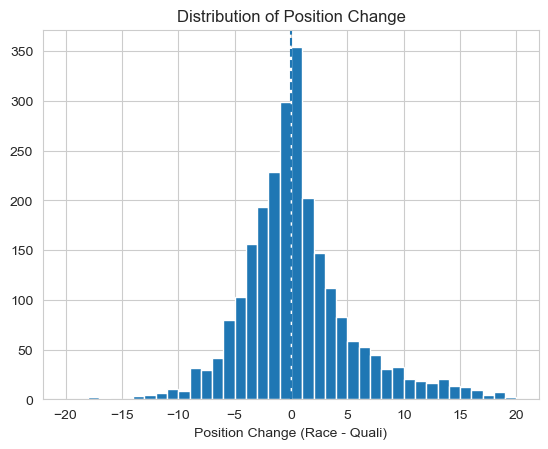

In [40]:
# summary stats
print(eda_df["PosChange"].describe())

# geetting the proportions
print("\nStayed the same:", (eda_df["PosChange"] == 0).mean())
print("Gained places:", (eda_df["PosChange"] < 0).mean())
print("Lost places:", (eda_df["PosChange"] > 0).mean())

# histogram
plt.hist(eda_df["PosChange"], bins=range(-20,21))
plt.axvline(0, linestyle="--")
plt.xlabel("Position Change (Race - Quali)")
plt.title("Distribution of Position Change")

plt.show()

<i><b>By CircuitType</b></i> I've already divided the circuits into type, so I'll redo the previous analysis but now considering cricuit classification. I repeat spearman correlation, plot by circuit type, and distribution change by circuit type. The relationship is consistently strong across the levels of "Street", "Technical", and "High Speed". This suggests that circuit type may in fact not matter as much. However, a conclusive result can only be given by a model which will take more factors into account

In [41]:
# spearmann correlation by circuit type

rows = []
for ct in eda_df["CircuitType"].dropna().unique():
    sub = eda_df[eda_df["CircuitType"] == ct]
    rho, p = stats.spearmanr(sub["QualiPos"], sub["RacePos"])
    rows.append([ct, rho, len(sub)])

circuit_table = pd.DataFrame(rows, columns=["CircuitType", "SpearmanRho", "n"])
print(circuit_table)

  CircuitType  SpearmanRho     n
0      Street     0.641250   517
1   Technical     0.646863  1178
2   HighSpeed     0.645456   739


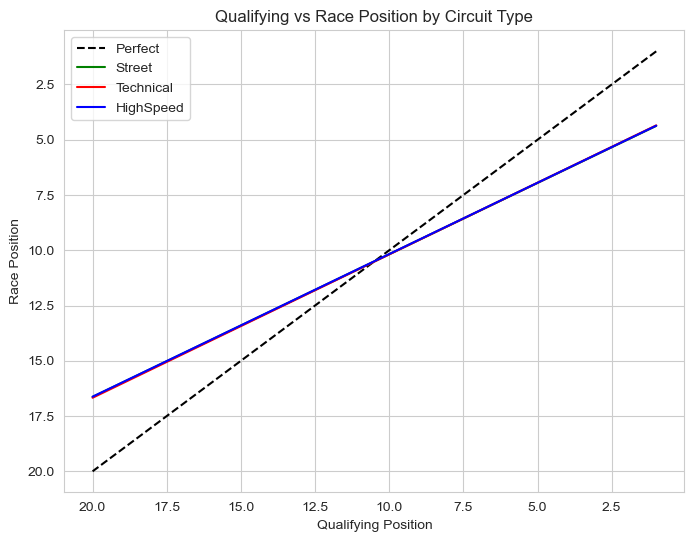

In [42]:
# plot by circuit type
plt.figure(figsize=(8,6))

# perfect line
plt.plot([1,20], [1,20], "--", color="black", label="Perfect")

colors = {"HighSpeed": "blue", "Street": "green", "Technical": "red"}

for ct in eda_df["CircuitType"].dropna().unique():
    sub = eda_df[eda_df["CircuitType"] == ct]
    z = np.polyfit(sub["QualiPos"], sub["RacePos"], 1)
    plt.plot([1,20], np.poly1d(z)([1,20]), color=colors.get(ct, "gray"), label=ct)

plt.xlabel("Qualifying Position")
plt.ylabel("Race Position")
plt.title("Qualifying vs Race Position by Circuit Type")
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.legend()
plt.show()

Street
count    517.000000
mean       0.032882
std        4.855358
min      -13.000000
25%       -3.000000
50%        0.000000
75%        2.000000
max       19.000000
Name: PosChange, dtype: float64
Technical
count    1178.000000
mean        0.019525
std         4.845318
min       -18.000000
25%        -3.000000
50%         0.000000
75%         2.000000
max        19.000000
Name: PosChange, dtype: float64
HighSpeed
count    739.000000
mean      -0.001353
std        4.854383
min      -17.000000
25%       -3.000000
50%       -1.000000
75%        2.000000
max       18.000000
Name: PosChange, dtype: float64


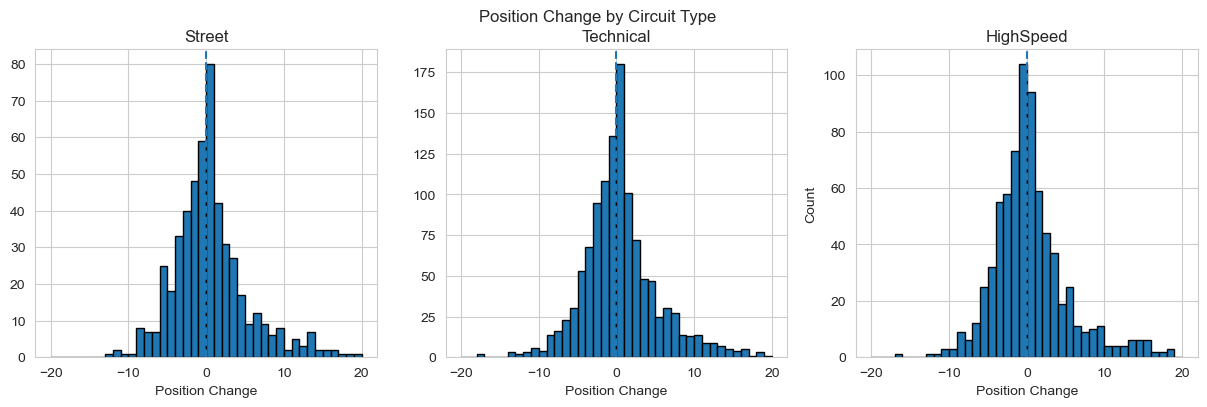

In [43]:
# distribution of position change by circuit type

circuit_types = eda_df["CircuitType"].dropna().unique()

plt.figure(figsize=(15,4))

for i, ct in enumerate(circuit_types, 1):
    sub = eda_df[eda_df["CircuitType"] == ct]

    print(ct)
    print(sub["PosChange"].describe())

    plt.subplot(1, 3, i)
    plt.hist(sub["PosChange"], bins=range(-20, 21), edgecolor="black")
    plt.axvline(0, linestyle="--")
    plt.title(ct)
    plt.xlabel("Position Change")

plt.ylabel("Count")
plt.suptitle("Position Change by Circuit Type")
plt.show()

<i><b>By ERA</b></i>
Now again I redo spearman, plot, and position change this time considering the two different regulatory eras, pre-2022 and post-2022. 
There is slightly more variation, with pre-2022 ρ = 0.616 and post-2022 ρ = 0.697. This actually indicates that, as opposed to my hypothesis, the regulatory changes have not actually weakened the dependence of the race outcome on qualifying performances. 

In [44]:
# spearmann correlation
rows = []
for era in ["Pre-2022", "Post-2022"]:
    sub = eda_df[eda_df["Era"] == era]
    rho, _ = stats.spearmanr(sub["QualiPos"], sub["RacePos"])
    rows.append([era, rho, len(sub)])

era_table = pd.DataFrame(rows, columns=["Era", "SpearmanRho", "n"])
print(era_table)

         Era  SpearmanRho     n
0   Pre-2022     0.616408  1557
1  Post-2022     0.696932   877


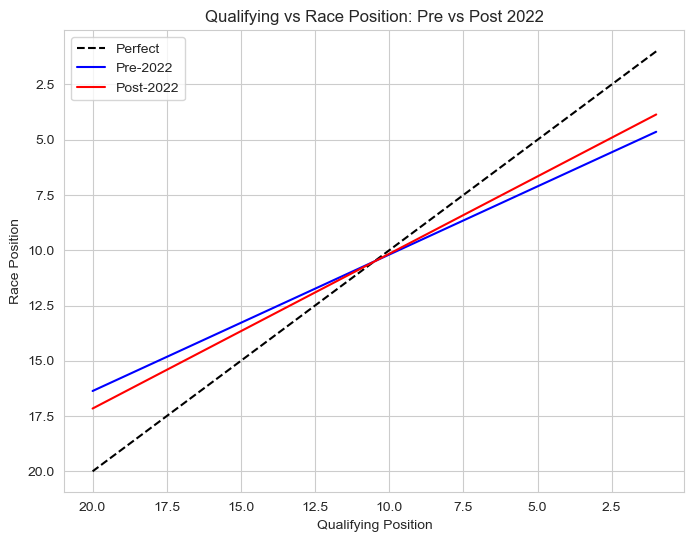

In [45]:
# plot

plt.figure(figsize=(8,6))
plt.plot([1,20], [1,20], "--", color="black", label="Perfect")

colors = {"Pre-2022": "blue", "Post-2022": "red"}

for era in ["Pre-2022", "Post-2022"]:
    sub = eda_df[eda_df["Era"] == era]
    z = np.polyfit(sub["QualiPos"], sub["RacePos"], 1)
    plt.plot([1,20], np.poly1d(z)([1,20]), color=colors[era], label=era)

plt.xlabel("Qualifying Position")
plt.ylabel("Race Position")
plt.title("Qualifying vs Race Position: Pre vs Post 2022")
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.legend()
plt.show()

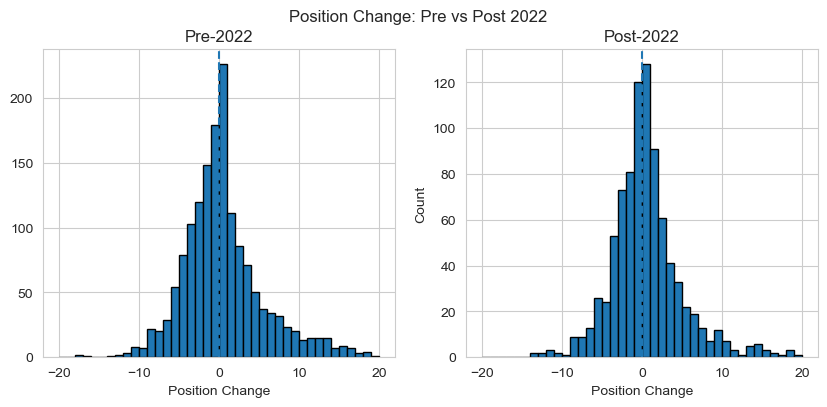

In [46]:
# position change histograms

plt.figure(figsize=(10,4))

for i, era in enumerate(["Pre-2022", "Post-2022"], 1):
    sub = eda_df[eda_df["Era"] == era]
    plt.subplot(1, 2, i)
    plt.hist(sub["PosChange"], bins=range(-20, 21), edgecolor="black")
    plt.axvline(0, linestyle="--")
    plt.title(era)
    plt.xlabel("Position Change")

plt.ylabel("Count")
plt.suptitle("Position Change: Pre vs Post 2022")
plt.show()

<i><b>Further Model Motivation</b></i>

From my EDA, I have 3 main shallow takeaways. First, as expected, qualifying position and race outcome are highly correlated. Next, surpsingly, circuit type does not affect the variability of position change in this initial exploration. And that the regulation introduced in 2022 does not in fact increase overtaking capabilities. However, these initial statistical tools do not consider all nuances and do not account for all the variability in the race outcomes, so I need another tool to properly quantify the relationship and the variables I'm considering. To formally test this, I propose a multinomial logistic regression model. 

<b>5. Multinomial Logistic Regression Base Model with Elastic-Net Regularisation</b>
I'm using multinomial logistic regression because the outcome variable (final race position) could belong to 1 of 3 categories and I want to model how the qualifying position relates to the probability of each final category. I'm using elastic net instead of just lasso or ridge because it is a combination of both and so helps with stabilising coefficient estimates (ridge) and feature selection by removing weak predictors (lasso) to avoid overfitting. 

<i><b>Data Setup</b></i> I'm usng the data from the dataset we already created and modifying it further for this model by setting the predictors and outcome.

In [51]:
# using a copy dataset
df = event_driver_df.copy()

# definign the target
TARGET = "Outcome"

# dropping rows with missing target or key predictor
df = df.dropna(subset=[TARGET, "QualiPos"]).copy()

# drop unneeded columns
DROP_COLS = [
    "Outcome", "DriverNumber", "Abbreviation", "FullName",
    "RacePos", "Status", "EventName"]

df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# convert time data columns to numeric so I can scale them
for col in df.columns:
    if "timedelta" in str(df[col].dtype):
        df[col] = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()


# choosing my variables
numeric_features = ["QualiPos"]
categorical_features = ["TeamName", "Era", "CircuitType"]

# setting x and y variables
X = df[numeric_features + categorical_features]
y = event_driver_df.loc[df.index, TARGET]


# examining dataset
print("Shape:", X.shape)
print("Class counts:\n", y.value_counts())
print("Class proportions:\n", y.value_counts(normalize=True))

Shape: (2474, 4)
Class counts:
 NoPoints    1235
Points       867
Podium       372
Name: Outcome, dtype: int64
Class proportions:
 NoPoints    0.499192
Points      0.350445
Podium      0.150364
Name: Outcome, dtype: float64


<i><b>Train/Test Split</b></i> I defined a 20% test size and 80% for training, using stratify so that the test set doesn't oversample or undersample a specific class.

In [52]:
# train / test split
X_train, X_test, y_train, y_test = train_test_split( 
    X, y, test_size=0.20, random_state=5, stratify=y)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (1979, 4) Test shape: (495, 4)


<i><b>Pre-processing Pipeline</b></i> some preprocessing based on numerical and categorical columns. First I defined them and use median imputation and scale for numerical, and most frequent imputer for categorical and one hot encoder.

In [54]:
# setting numerical and categorical columns and ensuring consistency
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist() 
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

print(f"Numeric cols: {len(numeric_cols)}")
print(f"Categorical cols: {len(categorical_cols)}")

to_str = FunctionTransformer(lambda X: X.astype("string"), feature_names_out="one-to-one")

# imputation and scale for numerical
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), 
    ("scaler", StandardScaler())])

# for categorical data
cat_pipe = Pipeline(steps=[
    ("to_str", to_str),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))])

# combining
preprocess = ColumnTransformer( 
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols),],
    remainder="drop" )

Numeric cols: 1
Categorical cols: 3


<i><b>SGD Classifier</b></i> To define the Elasic Net logistic model, I used the SGD Classifier so that it's a mixture of Lasso and Ridge. In this I also used balanced classes.

In [55]:
sgd = SGDClassifier( 
    loss="log_loss", 
    penalty="elasticnet", 
    max_iter=2000, 
    tol=1e-3, 
    early_stopping=True, 
    validation_fraction=0.1, 
    n_iter_no_change=5, 
    class_weight="balanced", 
    random_state=5
)

# preprocessing then model combining them into one pipeline.
pipe = Pipeline(steps=[ 
    ("preprocess", preprocess), 
    ("clf", sgd)
])

<i><b>Cross Validation</b></i> For Cross Validation, I used 5-fold again with 40 random candidate settings, so 200 total fits. The best fit is measured on f1_macro so that all classes matter equally.

In [57]:
try:
    from scipy.stats import loguniform
    SCIPY_OK = True 
except Exception:
    SCIPY_OK = False 
    
# 5-fold cv
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

# defining the hyperparameter search for both alpha and l1_ratio
if SCIPY_OK: 
    param_dist = {
        "clf__alpha": loguniform(1e-5, 1e-2),
        "clf__l1_ratio": np.linspace(0.05, 0.95, 10)}
    
else:
    param_dist = {
        "clf__alpha": [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
        "clf__l1_ratio": [0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95],}

search = RandomizedSearchCV( 
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40, # 40 random searches
    scoring="f1_macro", 
    cv=cv, 
    random_state=5, 
    verbose=2, 
    n_jobs=1, 
    refit=True,
    error_score="raise")

search.fit(X_train, y_train)

print("\nBest params:", search.best_params_)
print("Best CV macro-F1:", search.best_score_)

best_model = search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END clf__alpha=4.634250583294877e-05, clf__l1_ratio=0.65; total time=   0.0s
[CV] END clf__alpha=4.634250583294877e-05, clf__l1_ratio=0.65; total time=   0.0s
[CV] END clf__alpha=4.634250583294877e-05, clf__l1_ratio=0.65; total time=   0.0s
[CV] END clf__alpha=4.634250583294877e-05, clf__l1_ratio=0.65; total time=   0.0s
[CV] END clf__alpha=4.634250583294877e-05, clf__l1_ratio=0.65; total time=   0.0s
[CV] END clf__alpha=0.0001233703200243974, clf__l1_ratio=0.95; total time=   0.0s
[CV] END clf__alpha=0.0001233703200243974, clf__l1_ratio=0.95; total time=   0.0s
[CV] END clf__alpha=0.0001233703200243974, clf__l1_ratio=0.95; total time=   0.0s
[CV] END clf__alpha=0.0001233703200243974, clf__l1_ratio=0.95; total time=   0.0s
[CV] END clf__alpha=0.0001233703200243974, clf__l1_ratio=0.95; total time=   0.0s
[CV] END clf__alpha=0.0002918996447127882, clf__l1_ratio=0.75; total time=   0.0s
[CV] END clf__alpha=0.00029189964471

[CV] END clf__alpha=0.0007053009907918907, clf__l1_ratio=0.35; total time=   0.0s
[CV] END clf__alpha=0.0007053009907918907, clf__l1_ratio=0.35; total time=   0.0s
[CV] END clf__alpha=0.002808685027772651, clf__l1_ratio=0.75; total time=   0.0s
[CV] END clf__alpha=0.002808685027772651, clf__l1_ratio=0.75; total time=   0.0s
[CV] END clf__alpha=0.002808685027772651, clf__l1_ratio=0.75; total time=   0.0s
[CV] END clf__alpha=0.002808685027772651, clf__l1_ratio=0.75; total time=   0.0s
[CV] END clf__alpha=0.002808685027772651, clf__l1_ratio=0.75; total time=   0.0s
[CV] END clf__alpha=0.009054682122929985, clf__l1_ratio=0.15; total time=   0.0s
[CV] END clf__alpha=0.009054682122929985, clf__l1_ratio=0.15; total time=   0.0s
[CV] END clf__alpha=0.009054682122929985, clf__l1_ratio=0.15; total time=   0.0s
[CV] END clf__alpha=0.009054682122929985, clf__l1_ratio=0.15; total time=   0.0s
[CV] END clf__alpha=0.009054682122929985, clf__l1_ratio=0.15; total time=   0.0s
[CV] END clf__alpha=0.0040

<i><b>Model Evaluation: Confusion Matrix</b></i> Then on the test set I see how well my model does by evaluating Accuracy, Macro-F1 and Weighted F-1, and a classificaton report for individual classes. Then I created a heatmap confusion matrix for some visualisation.

Test Accuracy: 0.6848484848484848
Test Macro-F1: 0.6657020979034676
Test Weighted-F1: 0.6881663811298847

Classification report:
               precision    recall  f1-score   support

    NoPoints       0.82      0.73      0.78       247
      Podium       0.53      0.80      0.63        74
      Points       0.61      0.57      0.59       174

    accuracy                           0.68       495
   macro avg       0.65      0.70      0.67       495
weighted avg       0.70      0.68      0.69       495



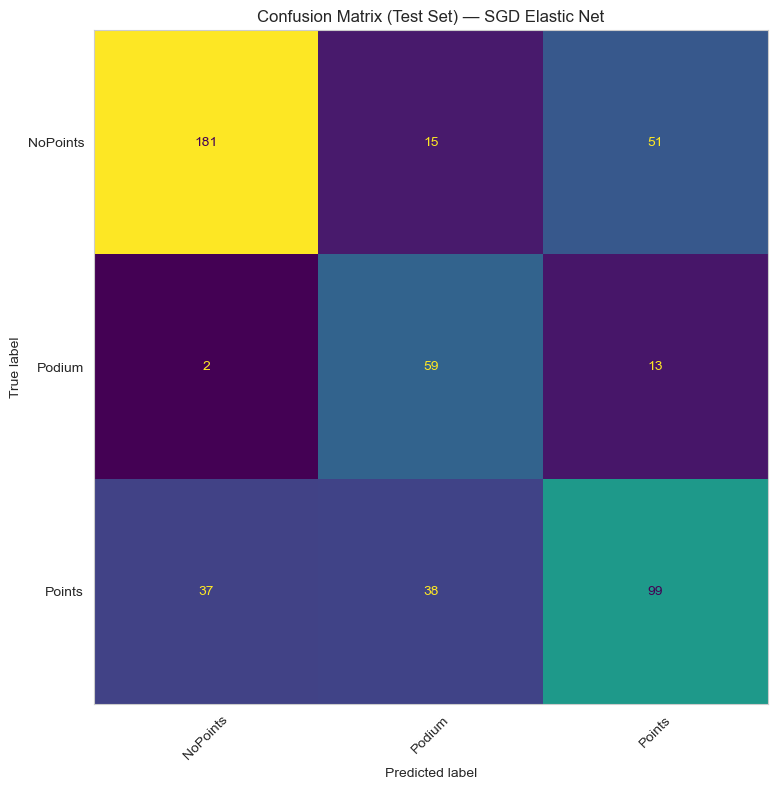

ROC-AUC macro (OVR): 0.8379708314136137
ROC-AUC weighted (OVR): 0.8230189284833913


In [58]:
# # predicting on test set
y_pred = best_model.predict(X_test)

has_proba = hasattr(best_model.named_steps["clf"], "predict_proba") 
if has_proba:
    y_proba = best_model.predict_proba(X_test)

# computing metrics
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Macro-F1:", f1_score(y_test, y_pred, average="macro")) 
print("Test Weighted-F1:", f1_score(y_test, y_pred, average="weighted")) 
print("\nClassification report:\n", classification_report(y_test, y_pred))

# creating the confusion matrix graph
cm = confusion_matrix(y_test, y_pred, labels=best_model.named_steps["clf"].classes_) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.named_steps["clf"].classes_) 

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False) 
plt.title("Confusion Matrix (Test Set) — SGD Elastic Net") 
plt.tight_layout()
ax.grid(False)
plt.show()

# avoiding error while computing ROC-AUC
if has_proba: 
    try:
        auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro") 
        auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted") 
        print("ROC-AUC macro (OVR):", auc_macro)
        print("ROC-AUC weighted (OVR):", auc_weighted)
    except ValueError as e: 
        print("ROC-AUC not computed:", e)
else:
    print("Note: This SGD configuration does not expose predict_proba; skipping ROC-AUC.")

<i><b>Base Model Performance</b></i>
The base model has an average accuracy of 0.68 and macro average (which accounts for class imbalance) of 0.67, which is pretty moderate and balanced across classes. The f1 score of the NoPoints classs is the highest (F1 = 0.78) which is to be expected as this is where the majority of racers are so has the largest number of datapoints. Podium, the smallest sample size, has a worse score of 0.63. Te middle class, Points, has the lowest F1 score of 0.59, which suggests the model doesn't do too well in this class. 

Overall, the ROC-AUC weighted macro of 0.823, which is decently good, confirming that the qualifying position, Team, Era, and CircuitType are good predictors.

However, this is just the base assumed relationship. It may very well be that, as supported by my EDA results, that there are inconstant contributions as determined by Era and CircuitType that causes prediction to vary. Mainly, the regulation change (as categorised by Era) changes overtaking ability as well as the prediction power of qualifying result to final position. CircuitType as well affects overtaking ability. Both these in tandem may cause further changes, which is why I must change the model a little bit to account for these changes. As I cannot exactly say for certain whether the factor affects the model performance, I will implement tree different models with interaction terms. The first one accounts for just Era, the second CircuitType, and the third both Era and CircuitType. By comparing the accuracy of these, I can get a better understanding of these factors and how they influence the final race position. 

<b>6. Model 2: Adding Interaction Terms</b>

Now extending the previous basemodel, which only assumes additive effects and does not help me differentiate context-dependant relationships. To see whether the relationship between qualifying position and final race position is weaker or stronger when Era or CircuitType of both are taken into account, I will create 3 interaction models and evaluate. 

<i><b>QualiPos x Era</b></i> I have already defined the main pipeline and additional functions necessary for multinomial logistic regression with elastic-net regularisation, so below I only make changes to x, y's defintion, the interaction variable, and then implement the new pipeline with updated x, y. 


In [62]:
# using a copy dataset
df2 = event_driver_df.copy()

# definign the target
TARGET = "Outcome"

# dropping rows with missing target or key predictor
df2 = df2.dropna(subset=[TARGET, "QualiPos"]).copy()

# drop unneeded columns
DROP_COLS = [
    "Outcome", "DriverNumber", "Abbreviation", "FullName",
    "RacePos", "Status", "EventName"]

df2 = df2.drop(columns=[c for c in DROP_COLS if c in df2.columns])

# convert time data columns to numeric so I can scale them
for col in df2.columns:
    if "timedelta" in str(df2[col].dtype):
        df2[col] = pd.to_timedelta(df2[col], errors="coerce").dt.total_seconds()

# adding interaction term for quali position and era
df2["Era_Post2022"] = (df2["Era"] == "Post-2022").astype(int)
df2["QualiPos_x_Era"] = df2["QualiPos"] * df2["Era_Post2022"]

# choosing my variables
numeric_features = ["QualiPos", "QualiPos_x_Era"]
categorical_features = ["TeamName", "Era", "CircuitType"]

# setting x and y variables
X2 = df2[numeric_features + categorical_features]
y2 = event_driver_df.loc[df2.index, TARGET]

# train / test split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=5, stratify=y2)

# setting numerical and categorical columns and ensuring consistency
numeric_cols = X2_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X2_train.columns if c not in numeric_cols]

# imputation and scale for numerical
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

# for categorical data
cat_pipe = Pipeline(steps=[
    ("to_str", to_str),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))])

# combining
preprocess2 = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols),],
    remainder="drop")

# preprocessing then model combining them into one pipeline
pipe2 = Pipeline(steps=[
    ("preprocess", preprocess2),
    ("clf", sgd)])

# random search again with the same settings as base model
search2 = RandomizedSearchCV(
    estimator=pipe2,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_macro",
    cv=cv,
    random_state=5,
    verbose=0,
    n_jobs=1,
    refit=True,
    error_score="raise")

search2.fit(X2_train, y2_train)

print("\nBest params (Model 2: QualiPos x Era):", search2.best_params_)
print("Best CV macro-F1 (Model 2: QualiPos x Era):", search2.best_score_)

best_model2 = search2.best_estimator_


Best params (Model 2: QualiPos x Era): {'clf__alpha': 0.000805505697740027, 'clf__l1_ratio': 0.5499999999999999}
Best CV macro-F1 (Model 2: QualiPos x Era): 0.6505082872483846


Test Accuracy: 0.6828282828282828
Test Macro-F1: 0.6665197834822191
Test Weighted-F1: 0.6859070661114266

Classification report:
               precision    recall  f1-score   support

    NoPoints       0.82      0.72      0.77       247
      Podium       0.54      0.80      0.64        74
      Points       0.60      0.57      0.59       174

    accuracy                           0.68       495
   macro avg       0.65      0.70      0.67       495
weighted avg       0.70      0.68      0.69       495



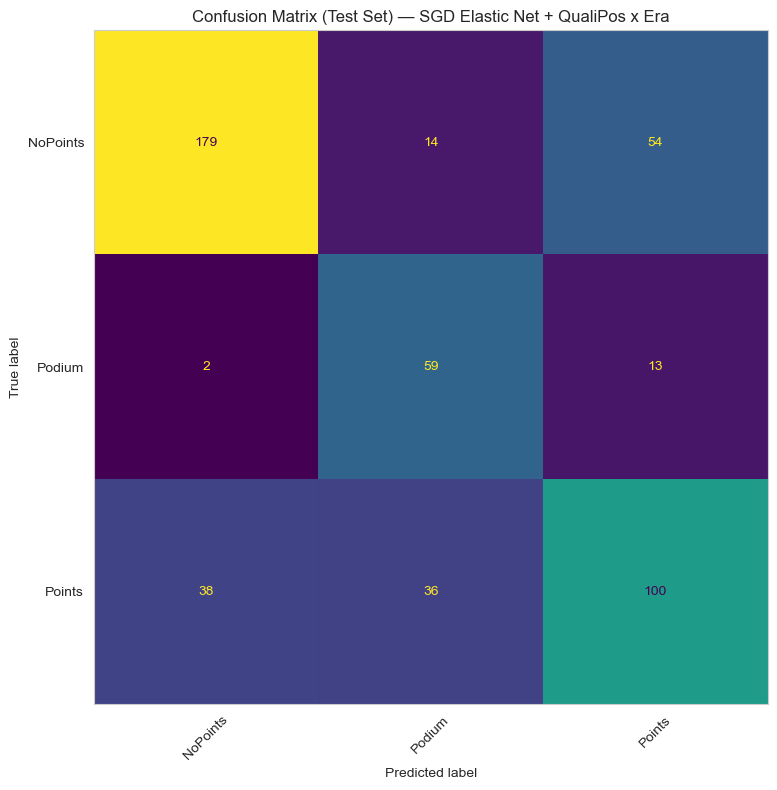

ROC-AUC macro (OVR): 0.8390121402719067
ROC-AUC weighted (OVR): 0.8246653568475598


In [63]:
# predicting on test set
y2_pred = best_model2.predict(X2_test)
has_proba = hasattr(best_model2.named_steps["clf"], "predict_proba")

if has_proba:
    y2_proba = best_model2.predict_proba(X2_test)

# computing metrics
print("Test Accuracy:", accuracy_score(y2_test, y2_pred))
print("Test Macro-F1:", f1_score(y2_test, y2_pred, average="macro"))
print("Test Weighted-F1:", f1_score(y2_test, y2_pred, average="weighted"))

print("\nClassification report:\n", classification_report(y2_test, y2_pred))

# creating the confusion matrix graph
cm = confusion_matrix(y2_test, y2_pred, labels=best_model2.named_steps["clf"].classes_)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model2.named_steps["clf"].classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix (Test Set) — SGD Elastic Net + QualiPos x Era")
plt.tight_layout()
ax.grid(False)
plt.show()

# avoiding error while computing ROC-AUC
if has_proba:
    try:
        auc_macro = roc_auc_score(y2_test, y2_proba, multi_class="ovr", average="macro")
        auc_weighted = roc_auc_score(y2_test, y2_proba, multi_class="ovr", average="weighted")
        print("ROC-AUC macro (OVR):", auc_macro)
        print("ROC-AUC weighted (OVR):", auc_weighted)
    except ValueError as e:
        print("ROC-AUC not computed:", e)
else:
    print("Note: This SGD configuration does not expose predict_proba; skipping ROC-AUC.")

<i><b>Model 2: Qualifying Position × Era Result</b></i>
This model has an additional interaction term from the base model of qualifying position x era. The results are very similar to the base model, again with a macro average of accuracy of 0.67. Nearly the same F1 score for the individual classes, and an ROC-AUC weighted of 0.825, only very slightly better than the base model's 0.823. 

This means that the incorporation of the interaction term QualiPos x Era, does not improve the model's performance nor does it make it worse. So the relaitonship between qualifying result and final posiiton is largely consistent across the eras of pre-2022 and post-2022. This means that the regulation introduced in 2022 intended to increase overtaking may not have succeeded. However, before any conclusion, we must still consider circuit type. 

<i><b>QualiPos x CircuitType</b></i>
Different Circuit Types (street, highspeed, technical) affect overtaking ability which affects the magnitude of influence of qualifying position to final race position. To quantify this, I'll implement QualiPos x CircuitType as an interaction term. The code for adding this as an interaction term is largely the same, so I've just reused what i've done above. However, circuit type is categorical. 

In [66]:
# using a copy dataset
df3 = event_driver_df.copy()

# definign the target
TARGET = "Outcome"

# dropping rows with missing target or key predictor
df3 = df3.dropna(subset=[TARGET, "QualiPos"]).copy()

# drop unneeded columns
DROP_COLS = [
    "Outcome", "DriverNumber", "Abbreviation", "FullName",
    "RacePos", "Status", "EventName"]
df3 = df3.drop(columns=[c for c in DROP_COLS if c in df3.columns])

# convert time data columns to numeric so I can scale them
for col in df3.columns:
    if "timedelta" in str(df3[col].dtype):
        df3[col] = pd.to_timedelta(df3[col], errors="coerce").dt.total_seconds()

# adding interaction term for quali position and circuit type
df3["QualiPos_x_Circuit"] = df3["QualiPos"].astype(str) + "_" + df3["CircuitType"].astype(str)

# choosing my variables
numeric_features = ["QualiPos"]
categorical_features = ["TeamName", "Era", "CircuitType", "QualiPos_x_Circuit"]

# setting x and y variables
X3 = df3[numeric_features + categorical_features]
y3 = event_driver_df.loc[df3.index, TARGET]

# train / test split
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.20, random_state=5, stratify=y3)

# setting numerical and categorical columns and ensuring consistency
numeric_cols = X3_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X3_train.columns if c not in numeric_cols]

# imputation and scale for numerical
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

# for categorical data
cat_pipe = Pipeline(steps=[
    ("to_str", to_str),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))])

# combining
preprocess3 = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols),],
    remainder="drop")

# preprocessing then model combining them into one pipeline
pipe3 = Pipeline(steps=[
    ("preprocess", preprocess3),
    ("clf", sgd)])

# random search again with the same settings as base model
search3 = RandomizedSearchCV(
    estimator=pipe3,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_macro",
    cv=cv,
    random_state=5,
    verbose=0,
    n_jobs=1,
    refit=True,
    error_score="raise")

search3.fit(X3_train, y3_train)

print("\nBest params (Model 3: QualiPos x CircuitType):", search3.best_params_)
print("Best CV macro-F1 (Model 3: QualiPos x CircuitType):", search3.best_score_)

best_model3 = search3.best_estimator_


Best params (Model 3: QualiPos x CircuitType): {'clf__alpha': 0.00035913188382540636, 'clf__l1_ratio': 0.75}
Best CV macro-F1 (Model 3: QualiPos x CircuitType): 0.6805288427350653


Test Accuracy: 0.703030303030303
Test Macro-F1: 0.6930692059094937
Test Weighted-F1: 0.7064548399524561

Classification report:
               precision    recall  f1-score   support

    NoPoints       0.82      0.72      0.76       247
      Podium       0.62      0.74      0.68        74
      Points       0.61      0.67      0.64       174

    accuracy                           0.70       495
   macro avg       0.68      0.71      0.69       495
weighted avg       0.72      0.70      0.71       495



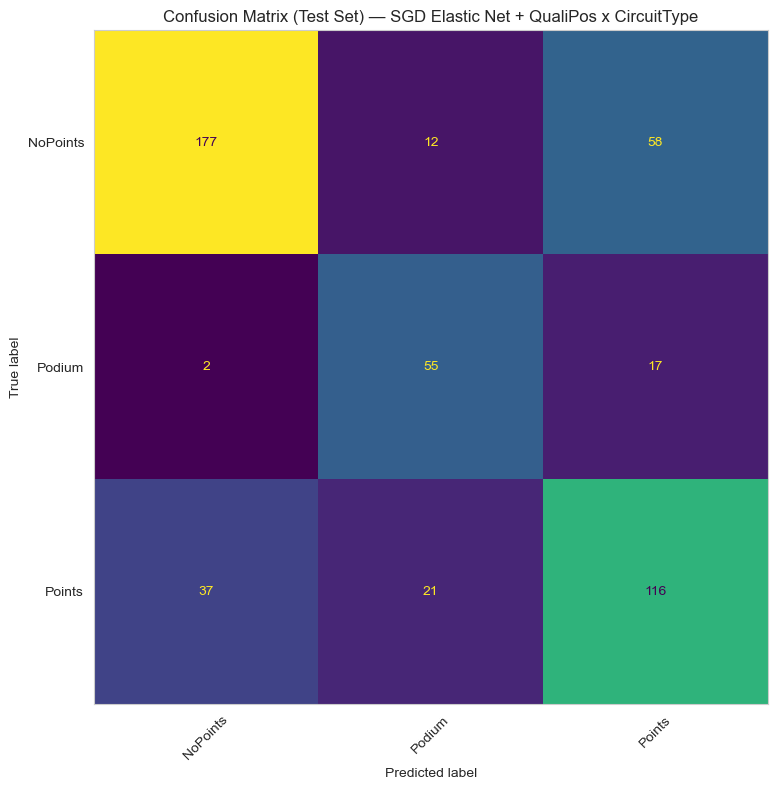

ROC-AUC macro (OVR): 0.8445849476943555
ROC-AUC weighted (OVR): 0.8297956486520026


In [67]:
# predicting on test set
y3_pred = best_model3.predict(X3_test)
has_proba = hasattr(best_model3.named_steps["clf"], "predict_proba")

if has_proba:
    y3_proba = best_model3.predict_proba(X3_test)

# computing metrics
print("Test Accuracy:", accuracy_score(y3_test, y3_pred))
print("Test Macro-F1:", f1_score(y3_test, y3_pred, average="macro"))
print("Test Weighted-F1:", f1_score(y3_test, y3_pred, average="weighted"))

print("\nClassification report:\n", classification_report(y3_test, y3_pred))

# creating the confusion matrix graph
cm = confusion_matrix(y3_test, y3_pred, labels=best_model3.named_steps["clf"].classes_)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model3.named_steps["clf"].classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix (Test Set) — SGD Elastic Net + QualiPos x CircuitType")
plt.tight_layout()
ax.grid(False)
plt.show()

# avoiding error while computing ROC-AUC
if has_proba:
    try:
        auc_macro = roc_auc_score(y3_test, y3_proba, multi_class="ovr", average="macro")
        auc_weighted = roc_auc_score(y3_test, y3_proba, multi_class="ovr", average="weighted")
        print("ROC-AUC macro (OVR):", auc_macro)
        print("ROC-AUC weighted (OVR):", auc_weighted)
    except ValueError as e:
        print("ROC-AUC not computed:", e)
else:
    print("Note: This SGD configuration does not expose predict_proba; skipping ROC-AUC.")

<i><b>Model 3: Qualifying Position × CircuitType Result</b></i>
By introducing the interaction term to the base model of circuit type with qualifying position, the model performs slightly better, slightly more significant than just Era. The main difference is the improvement of the F1 score in the classes of Points and Podium, which went from 0.59 to 0.64 and 0.63 to 0.64 respectively. The overall average macro accuracy also went up by 0.02. 

There is defintine quantifiable improvement by including circuit type, which matches my initial hypothesis, however it is not as large as expected.  

<i><b>Both Era and CircuitType</b></i> 
By including both era and circuit type interaction factors, my final model will be able to consider variations across both of these, allowing the model to contain more complex relationships. This will help with my understanding of Era and Circuit type influences on the qualifying position and final race position relationship. 


In [68]:
# using a copy dataset
df4 = event_driver_df.copy()

# definign the target
TARGET = "Outcome"

# dropping rows with missing target or key predictor
df4 = df4.dropna(subset=[TARGET, "QualiPos"]).copy()

# drop unneeded columns
DROP_COLS = [
    "Outcome", "DriverNumber", "Abbreviation", "FullName",
    "RacePos", "Status", "EventName"]

df4 = df4.drop(columns=[c for c in DROP_COLS if c in df4.columns])

# convert time data columns to numeric so I can scale them
for col in df4.columns:
    if "timedelta" in str(df4[col].dtype):
        df4[col] = pd.to_timedelta(df4[col], errors="coerce").dt.total_seconds()

# adding interaction term for quali position and era
df4["Era_Post2022"] = (df4["Era"] == "Post-2022").astype(int)
df4["QualiPos_x_Era"] = df4["QualiPos"] * df4["Era_Post2022"]

# adding interaction term for quali position and circuit type
df4["QualiPos_x_Circuit"] = df4["QualiPos"].astype(str) + "_" + df4["CircuitType"].astype(str)

# choosing my variables
numeric_features = ["QualiPos", "QualiPos_x_Era"]
categorical_features = ["TeamName", "Era", "CircuitType", "QualiPos_x_Circuit"]

# setting x and y variables
X4 = df4[numeric_features + categorical_features]
y4 = event_driver_df.loc[df4.index, TARGET]

# train / test split
X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.20, random_state=5, stratify=y4)

# setting numerical and categorical columns and ensuring consistency
numeric_cols = X4_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X4_train.columns if c not in numeric_cols]

# imputation and scale for numerical
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

# for categorical data
cat_pipe = Pipeline(steps=[
    ("to_str", to_str),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))])

# combining
preprocess4 = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols),],
    remainder="drop")

# preprocessing then model combining them into one pipeline
pipe4 = Pipeline(steps=[
    ("preprocess", preprocess4),
    ("clf", sgd)])

# random search again with the same settings as base model
search4 = RandomizedSearchCV(
    estimator=pipe4,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_macro",
    cv=cv,
    random_state=5,
    verbose=0,
    n_jobs=1,
    refit=True,
    error_score="raise")

search4.fit(X4_train, y4_train)

print("\nBest params (Model 4: QualiPos x Era and CircuitType):", search4.best_params_)
print("Best CV macro-F1 (Model 4: QualiPos x Era and CircuitType):", search4.best_score_)

best_model4 = search4.best_estimator_


Best params (Model 4: QualiPos x Era and CircuitType): {'clf__alpha': 0.001257566160028613, 'clf__l1_ratio': 0.75}
Best CV macro-F1 (Model 4: QualiPos x Era and CircuitType): 0.6811161240353762


Test Accuracy: 0.7090909090909091
Test Macro-F1: 0.6909287385923278
Test Weighted-F1: 0.712520714480201

Classification report:
               precision    recall  f1-score   support

    NoPoints       0.82      0.74      0.78       247
      Podium       0.62      0.68      0.65        74
      Points       0.61      0.68      0.64       174

    accuracy                           0.71       495
   macro avg       0.69      0.70      0.69       495
weighted avg       0.72      0.71      0.71       495



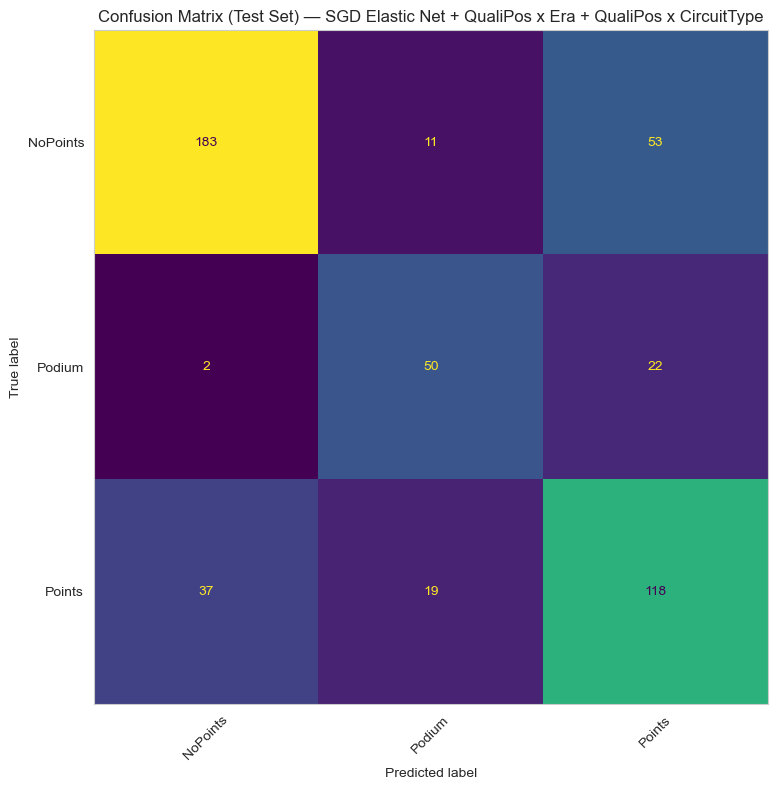

ROC-AUC macro (OVR): 0.8504292556968437
ROC-AUC weighted (OVR): 0.8360806488888575


In [69]:
# predicting on test set
y4_pred = best_model4.predict(X4_test)
has_proba = hasattr(best_model4.named_steps["clf"], "predict_proba")

if has_proba:
    y4_proba = best_model4.predict_proba(X4_test)

# computing metrics
print("Test Accuracy:", accuracy_score(y4_test, y4_pred))
print("Test Macro-F1:", f1_score(y4_test, y4_pred, average="macro"))
print("Test Weighted-F1:", f1_score(y4_test, y4_pred, average="weighted"))

print("\nClassification report:\n", classification_report(y4_test, y4_pred))

# creating the confusion matrix graph
cm = confusion_matrix(y4_test, y4_pred, labels=best_model4.named_steps["clf"].classes_)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model4.named_steps["clf"].classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix (Test Set) — SGD Elastic Net + QualiPos x Era + QualiPos x CircuitType")
plt.tight_layout()
ax.grid(False)
plt.show()

# avoiding error while computing ROC-AUC
if has_proba:
    try:
        auc_macro = roc_auc_score(y4_test, y4_proba, multi_class="ovr", average="macro")
        auc_weighted = roc_auc_score(y4_test, y4_proba, multi_class="ovr", average="weighted")
        print("ROC-AUC macro (OVR):", auc_macro)
        print("ROC-AUC weighted (OVR):", auc_weighted)
    except ValueError as e:
        print("ROC-AUC not computed:", e)
else:
    print("Note: This SGD configuration does not expose predict_proba; skipping ROC-AUC.")

<b>7. Time Series</b>


<i><b>Motivation for Time Series Analysis</b></i>

The previous analysis and modelling primarily focus on the relationship between qualifying position and final race outcome, treating each race as a single observation. While this provides useful insight into overall predictive performance, it does not capture how race positions evolve throughout the race itself.

In reality, Formula 1 races are inherently dynamic processes, where driver positions change lap-by-lap due to overtaking, pit stops, and race strategy. As such, analysing only the starting and ending positions may overlook important temporal patterns that influence the final outcome.

Furthermore, the earlier results suggest that qualifying position is a strong predictor of race results, but it is unclear whether this is due to genuine dominance of starting position or because positions remain relatively stable throughout the race. A time series perspective allows us to examine the persistence and variability of driver positions over time, providing deeper insight into the underlying race dynamics.

Therefore, this section extends the analysis by incorporating time series methods, focusing on within-race position changes and temporal trends across seasons. This helps to better understand whether race outcomes are largely determined early on or whether significant variation occurs throughout the race.

For the code below, as I orginally learned coding for time series in R, I had to reference another source for the specific syntax to implement in python. I used a variety of sources for my own learning, but the main code I altered from the following website: https://filippomb.github.io/python-time-series-handbook/notebooks/02/stationarity.html. 


# DRAFT

FOR BELOW
To quantify the dependence of positions across laps, the lag-1 autocorrelation (ρ₁) is computed. This measures how strongly a driver’s position in one lap depends on their position in the previous lap.

The results show that ρ₁ is consistently high (approximately 0.6–0.7), indicating strong persistence in driver positions throughout the race.
This high persistence suggests that the process exhibits strong temporal dependence, meaning that race positions evolve gradually rather than randomly across laps.For driver position:

𝜌
1
=
Corr
(
𝑃
𝑜
𝑠
𝑖
𝑡
𝑖
𝑜
𝑛
𝑡
,
 
𝑃
𝑜
𝑠
𝑖
𝑡
𝑖
𝑜
𝑛
𝑡
−
1
)
ρ
1
	​

=Corr(Position
t
	​

, Position
t−1
	​

)
ρ₁ ≈ 1 → positions barely change (very stable race)
ρ₁ ≈ 0 → positions are random
ρ₁ negative → chaotic switching (doesn’t really happen here)

# MAIN

In [78]:
import statsmodels.api as sm

In [79]:
# creating a race list for time series analysis
race_rows = []

schedule_ts = schedule_df.copy()
schedule_ts["CircuitType"] = schedule_ts["EventName"].apply(assign_circuit_type)
schedule_ts["Era"] = np.where(schedule_ts["Year"] < ERA_SPLIT_YEAR, "Pre-2022", "Post-2022")

# taking up to 5 races per circuit type within each era
for era in ["Pre-2022", "Post-2022"]:
    for ct in ["Street", "HighSpeed", "Technical"]:
        sub = schedule_ts[
            (schedule_ts["Era"] == era) &
            (schedule_ts["CircuitType"] == ct)
        ].head(5)
        
        if len(sub) > 0:
            race_rows.append(sub)

race_list_df = pd.concat(race_rows, ignore_index=True)

print(race_list_df[["Year", "Era", "RoundNumber", "EventName", "CircuitType"]])

    Year        Era  RoundNumber                  EventName CircuitType
0   2018   Pre-2022            1      Australian Grand Prix      Street
1   2018   Pre-2022            4      Azerbaijan Grand Prix      Street
2   2018   Pre-2022            6          Monaco Grand Prix      Street
3   2018   Pre-2022            7        Canadian Grand Prix      Street
4   2018   Pre-2022           15       Singapore Grand Prix      Street
5   2018   Pre-2022            9        Austrian Grand Prix   HighSpeed
6   2018   Pre-2022           10         British Grand Prix   HighSpeed
7   2018   Pre-2022           13         Belgian Grand Prix   HighSpeed
8   2018   Pre-2022           14         Italian Grand Prix   HighSpeed
9   2018   Pre-2022           17        Japanese Grand Prix   HighSpeed
10  2018   Pre-2022            2         Bahrain Grand Prix   Technical
11  2018   Pre-2022            3         Chinese Grand Prix   Technical
12  2018   Pre-2022            5         Spanish Grand Prix   Te

In [80]:
# computing lag-1 autocorrelation for selected races
ts_rows = []

for _, row in race_list_df.iterrows():
    year = row["Year"]
    round_num = row["RoundNumber"]
    event_name = row["EventName"]
    era = row["Era"]
    circuit_type = row["CircuitType"]
    
    try:
        session = fastf1.get_session(year, round_num, "R")
        session.load()
        
        laps = session.laps
        pos = laps[laps["Driver"] == "VER"]["Position"].dropna()
        
        if len(pos) > 1:
            rho_1 = sm.tsa.acf(pos, nlags=1)[1]
            
            ts_rows.append([
                year, era, round_num, event_name, circuit_type, "VER", rho_1
            ])
    
    except Exception as e:
        print(f"Skipped {year} {event_name}: {e}")

/Users/minaheelkhan/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:691: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


In [81]:
# creating final lag-1 autocorrelation table
ts_table = pd.DataFrame(
    ts_rows,
    columns=["Year", "Era", "Round", "EventName", "CircuitType", "Driver", "Lag1_Autocorr"]
)

ts_table["Lag1_Autocorr"] = ts_table["Lag1_Autocorr"].round(3)

print(ts_table)

    Year        Era  Round                  EventName CircuitType Driver  \
0   2018   Pre-2022      1      Australian Grand Prix      Street    VER   
1   2018   Pre-2022      4      Azerbaijan Grand Prix      Street    VER   
2   2018   Pre-2022      6          Monaco Grand Prix      Street    VER   
3   2018   Pre-2022      7        Canadian Grand Prix      Street    VER   
4   2018   Pre-2022     15       Singapore Grand Prix      Street    VER   
5   2018   Pre-2022      9        Austrian Grand Prix   HighSpeed    VER   
6   2018   Pre-2022     10         British Grand Prix   HighSpeed    VER   
7   2018   Pre-2022     13         Belgian Grand Prix   HighSpeed    VER   
8   2018   Pre-2022     14         Italian Grand Prix   HighSpeed    VER   
9   2018   Pre-2022     17        Japanese Grand Prix   HighSpeed    VER   
10  2018   Pre-2022      2         Bahrain Grand Prix   Technical    VER   
11  2018   Pre-2022      3         Chinese Grand Prix   Technical    VER   
12  2018   P

In [82]:
# summary by era and circuit type
ts_summary = (
    ts_table.groupby(["Era", "CircuitType"])["Lag1_Autocorr"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

ts_summary["mean"] = ts_summary["mean"].round(3)
ts_summary["std"] = ts_summary["std"].round(3)

print(ts_summary)

         Era CircuitType   mean    std  count
0  Post-2022   HighSpeed  0.842  0.056      5
1  Post-2022      Street  0.789  0.074      5
2  Post-2022   Technical  0.635  0.412      4
3   Pre-2022   HighSpeed  0.661  0.270      5
4   Pre-2022      Street  0.802  0.101      5
5   Pre-2022   Technical  0.656  0.463      5


In [83]:
# saving outputs
ts_table.to_csv("../data/ts_table.csv", index=False)
ts_summary.to_csv("../data/ts_summary.csv", index=False)

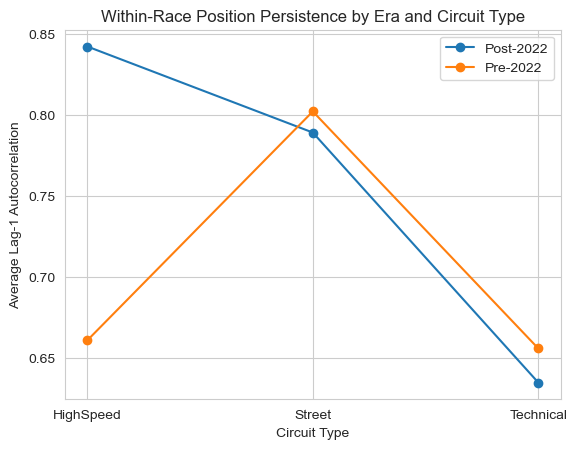

In [84]:
# plotting average lag-1 autocorrelation by era and circuit type
for era in ts_summary["Era"].unique():
    sub = ts_summary[ts_summary["Era"] == era]
    plt.plot(sub["CircuitType"], sub["mean"], marker="o", label=era)

plt.xlabel("Circuit Type")
plt.ylabel("Average Lag-1 Autocorrelation")
plt.title("Within-Race Position Persistence by Era and Circuit Type")
plt.legend()
plt.show()

(B) Your actual results — key numbers
From your main table:
Average lag-1 autocorrelation: 0.761
Individual races:
2019 R1: 0.801
2021 R3: 0.820
2023 R1: 0.647
2024 R2: 0.776

👉 Interpretation:

Most values are between 0.65 and 0.82
This is very high persistence
Key insight:

Driver position is strongly dependent on previous lap position, meaning overtaking is limited and gradual

(C) By Era + Circuit Type (your strongest result)

From your ts_summary:

Post-2022:
HighSpeed: 0.842
Street: 0.789
Technical: 0.635
Pre-2022:
HighSpeed: 0.661
Street: 0.802
Technical: 0.656
(D) What this actually means (THIS is what gets marks)
1. High persistence overall
All values are > 0.6
→ Positions evolve slowly
→ Race outcome largely determined early

💡 Link to your main model:

This explains why qualifying position is such a strong predictor
2. Regulation effect (very interesting!)

Compare:

Circuit	Pre-2022	Post-2022
HighSpeed	0.661	0.842 ↑
Street	0.802	0.789 ≈
Technical	0.656	0.635 ≈
Interpretation:
High-speed circuits became MORE stable after 2022
→ Overtaking may have actually decreased where it should have increased

💡 This supports your earlier finding:

Spearman correlation increased post-2022 (0.616 → 0.697)

3. Circuit-type effect
HighSpeed (post-2022 = 0.842) → MOST stable
Technical (~0.63–0.65) → MOST variable
Interpretation:
High-speed tracks:
Strong straight-line advantage
Hard to overtake once positions settle
Technical tracks:
More corners → more opportunities for change
4. Outliers (VERY IMPORTANT FOR MARKS)

From your table:

Example: -0.167 (2018 Technical)

👉 This is unusual:

Negative autocorrelation = positions reversing
Likely due to:
safety car
pit strategies
race incidents

💡 This shows:

While overall persistence is high, rare events introduce variability

🧠 2. Strong “Model-Level” Interpretation (link to RQ)

You should explicitly say:

The high lag-1 autocorrelation values (mean ≈ 0.76) indicate strong within-race persistence in driver positions. This suggests that race outcomes are largely path-dependent, meaning early advantages such as qualifying position are maintained throughout the race. This provides a mechanistic explanation for the strong predictive power of qualifying position observed in the multinomial logistic regression model.

That’s distinction-level linking.

# PACF

In [85]:
from statsmodels.tsa.stattools import pacf

pacf_vals = pacf(pos, nlags=3)
print("PACF:", pacf_vals)

PACF: [ 1.          0.93376602 -0.04946087 -0.02845449]


# volatility

In [86]:
pos_change = pos.diff().dropna()
volatility = pos_change.var()
# add to ts_rows
vol = pos.diff().dropna().var()

<b>8. Evaluations</b>